# CropWatch: Crop Health & Water Status Classifier
### Sentinel-2 Based Agricultural Field Monitoring

This notebook implements an end-to-end agricultural monitoring pipeline using Sentinel-2 satellite imagery. It produces:
- **Vegetation Health Map** (Healthy / Moderate Stress / High Stress)
- **Water Status Map** (Adequate / Mild Deficit / Strong Deficit)
- **Field Uniformity Analysis** with hotspot detection
- **Automated Agronomic Report**

Designed as a modular pipeline; Each section is a reusable function that can be integrated into a larger multi-field monitoring system.

This pipeline uses four spectral indices (NDVI, EVI, NDWI, NDMI) rather than a single index for more robust classification. Hotspot detection uses Isolation Forest + DBSCAN for multivariate spatial anomaly detection. An additional CHIRPS rainfall layer provides environmental context beyond the satellite signal alone.

**Data source:** Sentinel-2 Surface Reflectance (ESA Copernicus) via Google Earth Engine  
**Rainfall context:** CHIRPS Daily Precipitation via Google Earth Engine  
**Default field:** Po Valley, Italy (one of Europe's most intensively monitored agricultural regions)

---
## Section 0: Pipeline Configuration

All tunable parameters are defined here. If needed, edit this cell to change the field, date, or analysis thresholds.

This separation of config from logic makes the pipeline reusable across multiple fields by simply swapping the AOI and date parameters.

In [ ]:

# PIPELINE CONFIGURATION

# AOI
AOI_LAT = 45.15
AOI_LON = 11.80  # Near Padova --> flat farmland
AOI_BUFFER_KM   = 2.0           # Buffer radius in km (max ~5.6km for 10x10km cap)
AOI_MODE        = 'latlon'      # 'latlon' or 'draw' (draw requires map interaction below)

# Date
DATE_CENTER      = '2024-07-15' # Analysis date (YYYY-MM-DD)
DATE_WINDOW_DAYS = 10           # ± days around center date for composite
RAINFALL_LOOKBACK_DAYS = 30     # Days before analysis date for CHIRPS rainfall context

# Image Quality
CLOUD_THRESHOLD  = 20           # Max cloud cover % per scene

# Classification threshold
# Health (combined NDVI+EVI score): [healthy/moderate boundary, moderate/stress boundary]
HEALTH_THRESHOLDS = [0.5, 0.3]

# Water (combined NDWI+NDMI score): [adequate/mild boundary, mild/strong boundary]
WATER_THRESHOLDS  = [0.0, -0.3]

# Uniformity
# K-means clusters for NDVI spatial segmentation
N_CLUSTERS        = 3
# Score boundaries: [uniform/mixed, mixed/patchy]
UNIFORMITY_BINS   = [70, 40]

# Hotspot detection
# Isolation Forest: fraction of pixels treated as anomalies
ISOLATION_CONTAMINATION = 0.05
# DBSCAN spatial clustering parameters
DBSCAN_EPS        = 0.001       # Degrees (~100m at mid-latitudes)
DBSCAN_MIN_SAMPLES = 5
N_HOTSPOTS        = 5           # Max hotspot zones to report

#  GEE project
GEE_PROJECT       = 'projecttestrun'

print('Configuration loaded.')

Configuration loaded.


---
## Section 1: Setup & Authentication


In [ ]:
# Install packages
!pip install earthengine-api geemap geopandas shapely scikit-learn folium -q

In [ ]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import folium
from datetime import datetime, timedelta
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Authenticate and initialize GEE
#ee.Authenticate() # uncomment on first run only
ee.Initialize(project=GEE_PROJECT)

print('All libraries loaded. GEE initialized.')

All libraries loaded. GEE initialized.


---
## Section 2: AOI Definition

Two input modes:
- **`latlon`**: Provide a center coordinate + buffer → generates a square bounding box
- **`draw`**: Interactively draw a polygon on a map widget


In [ ]:
def latlon_to_aoi(lat, lon, buffer_km):
    """
    creates a square GEE geometry centered on (lat, lon)
    with a given buffer radius in km.

    returns: ee.Geometry.Polygon
    """
    # Convert km to degrees (approximate, valid at mid-latitudes)
    delta_deg = buffer_km / 111.0
    return ee.Geometry.BBox(
        lon - delta_deg,  # west
        lat - delta_deg,  # south
        lon + delta_deg,  # east
        lat + delta_deg   # north
    )


def validate_aoi_size(aoi, max_km2=100):
    """
    checks that the AOI does not exceed the maximum allowed area.
    raises ValueError if too large.

    max_km2: corresponds to 10x10 km = 100 km²
    """
    area_m2 = aoi.area(maxError=10).getInfo()
    area_km2 = area_m2 / 1e6
    if area_km2 > max_km2:
        raise ValueError(
            f'AOI area {area_km2:.1f} km² exceeds maximum allowed {max_km2} km². '
            f'Reduce AOI_BUFFER_KM in the configuration block.'
        )
    print(f'AOI validated: {area_km2:.2f} km² (max {max_km2} km²)')
    return area_km2


def define_aoi(mode='latlon', lat=AOI_LAT, lon=AOI_LON,
               buffer_km=AOI_BUFFER_KM, drawn_geometry=None):
    """
    main AOI definition function.

    mode: 'latlon' for coordinate + buffer, 'draw' for interactive polygon
    returns: ee.Geometry
    """
    if mode == 'latlon':
        aoi = latlon_to_aoi(lat, lon, buffer_km)
        print(f'AOI defined via lat/lon: center ({lat}, {lon}), buffer {buffer_km} km')
    elif mode == 'draw':
        if drawn_geometry is None:
            raise ValueError('drawn_geometry must be provided when mode="draw". '
                             'Run the interactive map cell below first.')
        aoi = drawn_geometry
        print('AOI defined via drawn polygon.')
    else:
        raise ValueError(f'Unknown mode "{mode}". Use "latlon" or "draw".')

    validate_aoi_size(aoi)
    return aoi


# Define AOI
AOI = define_aoi(mode=AOI_MODE)
print(f'\nAOI ready for analysis.')

AOI defined via lat/lon: center (45.15, 11.8), buffer 2.0 km
AOI validated: 11.32 km² (max 100 km²)

AOI ready for analysis.


In [ ]:

# draw  field polygon on the map, then run define_aoi(mode='draw', drawn_geometry=...)

draw_map = geemap.Map(center=[AOI_LAT, AOI_LON], zoom=12)
draw_map.add_basemap('SATELLITE')
draw_map

Map(center=[45.15, 11.8], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

---
## Section 3: Sentinel-2 Loading & Cloud Masking

**Collection:** `COPERNICUS/S2_SR_HARMONIZED` (Level-2A surface reflectance)
- Surface reflectance corrects for atmospheric scattering (important for reliable index computation)
- Harmonized ensures consistent values across Sentinel-2A and 2B platforms

**Cloud masking:** QA60 bitmask (bits 10+11 for clouds and cirrus)
- Standard ESA-recommended approach for field-level analysis
- Trade-off vs SCL: coarser but faster (appropriate for prototyping, noted as future improvement)

**Composite:** Median over all valid pixels in the ±10 day window
- More robust to residual cloud artifacts than a single date
- Still represents a coherent crop condition snapshot

In [ ]:
def mask_s2_clouds(image):
    """
    masks clouds and cirrus in a Sentinel-2 image using the QA60 bitmask band.
    Bit 10: opaque clouds | Bit 11: cirrus clouds

    returns: cloud-masked ee.Image with scale factor applied
    """
    qa = image.select('QA60')
    cloud_bit_mask  = 1 << 10
    cirrus_bit_mask = 1 << 11
    # Both flags must be zero (clear conditions)
    mask = (qa.bitwiseAnd(cloud_bit_mask).eq(0)
              .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0)))
    # Apply scale factor (S2 SR values are stored as int * 10000)
    return image.updateMask(mask).divide(10000)


def load_sentinel2(aoi, date_center, window_days=DATE_WINDOW_DAYS,
                   cloud_threshold=CLOUD_THRESHOLD):
    """
    loads and preprocesses a Sentinel-2 SR composite for the given AOI and date.

    args:
        aoi: ee.Geometry — field boundary
        date_center: str — analysis date 'YYYY-MM-DD'
        window_days: int — ± days around center date
        cloud_threshold: int — max scene-level cloud cover %

    returns:
        composite: ee.Image — median composite, cloud-masked, scaled
        n_images: int — number of scenes in composite
    """
    center_dt = datetime.strptime(date_center, '%Y-%m-%d')
    start_date = (center_dt - timedelta(days=window_days)).strftime('%Y-%m-%d')
    end_date   = (center_dt + timedelta(days=window_days)).strftime('%Y-%m-%d')

    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_threshold))
        .map(mask_s2_clouds)
    )

    n_images = collection.size().getInfo()

    if n_images == 0:
        raise ValueError(
            f'No Sentinel-2 scenes found for the given AOI and date range '
            f'({start_date} to {end_date}) with cloud cover < {cloud_threshold}%. '
            f'Try increasing DATE_WINDOW_DAYS or CLOUD_THRESHOLD in the config.'
        )

    # median composite: robust to residual cloud artifacts
    composite = collection.median().clip(aoi)

    print(f'Sentinel-2 composite loaded:')
    print(f'  Date window : {start_date} to {end_date}')
    print(f'  Scenes used : {n_images}')
    print(f'  Cloud filter: < {cloud_threshold}%')

    return composite, n_images


# load imagery
s2_composite, n_scenes = load_sentinel2(AOI, DATE_CENTER)

Sentinel-2 composite loaded:
  Date window : 2024-07-05 to 2024-07-25
  Scenes used : 4
  Cloud filter: < 20%


---
## Section 4: Spectral Index Computation

Four indices computed server-side in GEE before any local download.

| Index | Formula | Purpose |
|---|---|---|
| NDVI | (B8-B4)/(B8+B4) | Vegetation density & photosynthetic activity |
| EVI | 2.5*(B8-B4)/(B8+6B4-7.5B2+1) | NDVI saturation correction in dense canopy |
| NDWI | (B8-B11)/(B8+B11) | Canopy liquid water content (Gao 1996) |
| NDMI | (B8-B12)/(B8+B12) | Plant & soil moisture stress |

**Design choice:** NDVI+EVI jointly for health (agreement increases confidence); NDWI+NDMI jointly for water (independent moisture signals).

In [ ]:
def compute_indices(image):
    """
    computes vegetation and moisture indices from a Sentinel-2 image.
    all bands referenced by S2_SR_HARMONIZED naming convention.

    bands used:
        B2  = Blue  (10m) — EVI atmospheric correction
        B4  = Red   (10m) — NDVI, EVI
        B8  = NIR   (10m) — NDVI, EVI, NDWI, NDMI
        B11 = SWIR1 (20m) — NDWI (Gao 1996, canopy water)
        B12 = SWIR2 (20m) — NDMI (plant/soil moisture)

    returns: ee.Image with bands ['NDVI', 'EVI', 'NDWI', 'NDMI']
    """
    blue  = image.select('B2')
    red   = image.select('B4')
    nir   = image.select('B8')
    swir1 = image.select('B11')
    swir2 = image.select('B12')

    # NDVI: normalized difference vegetation index
    # high NDVI = dense healthy canopy; low NDVI = stressed or bare soil
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')

    # EVI: enhanced vegetation index (Huete et al., 2002)
    # Ccrrects for canopy background and atmospheric effects
    # less prone to saturation in dense crops than NDVI
    evi = (nir.subtract(red)
              .multiply(2.5)
              .divide(
                  nir.add(red.multiply(6))
                     .subtract(blue.multiply(7.5))
                     .add(1)
              )
              .rename('EVI'))

    # NDWI (Gao 1996): normalized difference water index
    # uses NIR/SWIR1 —> sensitive to liquid water in vegetation canopy
    # note: NOT the McFeeters NDWI (Green/NIR), which detects open water bodies
    ndwi = nir.subtract(swir1).divide(nir.add(swir1)).rename('NDWI')

    # NDMI: normalized difference moisture index
    # uses NIR/SWIR2 — sensitive to plant and soil moisture stress
    ndmi = nir.subtract(swir2).divide(nir.add(swir2)).rename('NDMI')

    return ee.Image([ndvi, evi, ndwi, ndmi])


# compute indices
indices = compute_indices(s2_composite)

# download index arrays for local ML steps
# geemap.ee_to_numpy downloads a small AOI as a numpy array

def download_band(image, band_name, aoi, scale=20):
    """
    downloads a single-band GEE image to a numpy array.
    scale=20m matches SWIR band resolution (coarsest band used).
    """
    band = image.select(band_name)
    arr = geemap.ee_to_numpy(band, region=aoi, scale=scale)
    if arr is None:
        raise ValueError(f'Failed to download band {band_name}. Check AOI and date.')
    return arr[:, :, 0].astype(np.float32)

SCALE = 20  # metres per pixel

ndvi_arr = download_band(indices, 'NDVI', AOI, SCALE)
evi_arr  = download_band(indices, 'EVI',  AOI, SCALE)
ndwi_arr = download_band(indices, 'NDWI', AOI, SCALE)
ndmi_arr = download_band(indices, 'NDMI', AOI, SCALE)

# mask NaN/Inf values (cloud-masked pixels or division by zero)
valid_mask = (
    np.isfinite(ndvi_arr) & np.isfinite(evi_arr) &
    np.isfinite(ndwi_arr) & np.isfinite(ndmi_arr)
)

print(f'Index arrays downloaded: shape {ndvi_arr.shape}')
print(f'Valid pixels: {valid_mask.sum()} / {valid_mask.size} ({100*valid_mask.mean():.1f}%)')
print(f'NDVI range: [{np.nanmin(ndvi_arr):.3f}, {np.nanmax(ndvi_arr):.3f}]')
print(f'NDWI range: [{np.nanmin(ndwi_arr):.3f}, {np.nanmax(ndwi_arr):.3f}]')

Index arrays downloaded: shape (202, 201)
Valid pixels: 40602 / 40602 (100.0%)
NDVI range: [-0.061, 0.954]
NDWI range: [-0.413, 0.569]


---
## Section 5: CHIRPS Rainfall Integration

Pulls 30-day cumulative precipitation for the AOI from CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) —> freely available in GEE at daily resolution.

**Why:** Rainfall context transforms water status from a number into an interpretation:
- Water deficit + low rainfall → likely drought stress
- Water deficit + adequate rainfall → likely irrigation/drainage/soil issue
- No deficit + low rainfall → crop may be irrigated or stress-resilient

This is the first step toward the multi-source environmental indicator pipeline.

In [ ]:
def get_rainfall_context(aoi, date_center, lookback_days=RAINFALL_LOOKBACK_DAYS):
    """
    retrieves mean cumulative precipitation (mm) over the AOI
    for the period [date_center - lookback_days, date_center].

    Data source: UCSB-CHG/CHIRPS/DAILY (0.05 degree resolution, daily)
    Available from 1981-01-01 to near-present.

    args:
        aoi: ee.Geometry
        date_center: str 'YYYY-MM-DD'
        lookback_days: int — agronomically relevant pre-analysis window

    returns:
        total_mm: float — cumulative mean precipitation over AOI
        daily_mm: float — mean daily precipitation
        rainfall_class: str — 'Low' / 'Moderate' / 'Adequate'
    """
    center_dt  = datetime.strptime(date_center, '%Y-%m-%d')
    start_date = (center_dt - timedelta(days=lookback_days)).strftime('%Y-%m-%d')

    chirps = (
        ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
        .filterBounds(aoi)
        .filterDate(start_date, date_center)
        .select('precipitation')
    )

    # sum daily precipitation across the window
    total_precip = chirps.sum().clip(aoi)

    # compute mean over AOI pixels
    mean_dict = total_precip.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=5000,   # CHIRPS native resolution ~5km
        maxPixels=1e6
    )

    total_mm = mean_dict.get('precipitation').getInfo()
    if total_mm is None:
        print('Warning: CHIRPS data unavailable for this region/date. Skipping rainfall context.')
        return None, None, 'Unknown'

    daily_mm = total_mm / lookback_days

    # classify rainfall (approximate thresholds for summer growing season)
    if total_mm < 20:
        rainfall_class = 'Low'
    elif total_mm < 60:
        rainfall_class = 'Moderate'
    else:
        rainfall_class = 'Adequate'

    print(f'CHIRPS Rainfall ({start_date} to {date_center}):')
    print(f'  Total  : {total_mm:.1f} mm over {lookback_days} days')
    print(f'  Daily  : {daily_mm:.2f} mm/day')
    print(f'  Class  : {rainfall_class}')

    return total_mm, daily_mm, rainfall_class


# get rainfall context
rainfall_total, rainfall_daily, rainfall_class = get_rainfall_context(AOI, DATE_CENTER)

CHIRPS Rainfall (2024-06-15 to 2024-07-15):
  Total  : 42.8 mm over 30 days
  Daily  : 1.43 mm/day
  Class  : Moderate


---
## Section 6: Vegetation Health Classification

Thresholds a weighted combination of NDVI and EVI into three agronomic health classes.

**Score:** `health = 0.6 * NDVI + 0.4 * EVI`  
NDVI weighted higher (more established); EVI acts as saturation correction.

**Thresholds** derived from ESA Sentinel-2 for Agriculture guidelines:
- Healthy (>0.5): active photosynthesis, good canopy closure
- Moderate Stress (0.3–0.5): reduced chlorophyll, early stress signal
- High Stress (<0.3): significant chlorophyll loss, possible crop failure zones

In [ ]:
def classify_health(ndvi, evi, thresholds=HEALTH_THRESHOLDS, valid_mask=None):
    """
    classifies vegetation health from NDVI and EVI arrays.

    args:
        ndvi, evi: 2D numpy arrays
        thresholds: [healthy_moderate_boundary, moderate_stress_boundary]
        valid_mask: 2D boolean array (optional)

    returns:
        health_map: 2D int array (1=Healthy, 2=Moderate, 3=High Stress, 0=NoData)
        percentages: dict with class percentages
        quadrant_stats: dict with per-quadrant dominant class
    """
    h_thresh, m_thresh = thresholds

    # combined health score: weighted average
    health_score = 0.6 * ndvi + 0.4 * evi

    # initialize map (0 = no data)
    health_map = np.zeros_like(health_score, dtype=np.int8)

    mask = valid_mask if valid_mask is not None else np.ones_like(health_score, dtype=bool)

    health_map[mask & (health_score >= h_thresh)]                        = 1  # Healthy
    health_map[mask & (health_score >= m_thresh) & (health_score < h_thresh)] = 2  # Moderate Stress
    health_map[mask & (health_score < m_thresh)]                         = 3  # High Stress

    # compute area percentages
    valid_pixels = mask.sum()
    percentages = {
        'Healthy'         : 100 * (health_map == 1).sum() / valid_pixels,
        'Moderate Stress' : 100 * (health_map == 2).sum() / valid_pixels,
        'High Stress'     : 100 * (health_map == 3).sum() / valid_pixels,
    }

    # quadrant analysis: split array into NW/NE/SW/SE
    rows, cols = health_map.shape
    hmid, vmid = rows // 2, cols // 2
    quadrants = {
        'NW': health_map[:hmid, :vmid],
        'NE': health_map[:hmid, vmid:],
        'SW': health_map[hmid:, :vmid],
        'SE': health_map[hmid:, vmid:],
    }
    class_labels = {1: 'Healthy', 2: 'Moderate Stress', 3: 'High Stress'}
    quadrant_stats = {}
    for q_name, q_arr in quadrants.items():
        valid_q = q_arr[q_arr > 0]
        if len(valid_q) > 0:
            dominant = int(np.bincount(valid_q).argmax())
            stress_pct = 100 * (valid_q >= 2).sum() / len(valid_q)
            quadrant_stats[q_name] = {
                'dominant_class': class_labels.get(dominant, 'Unknown'),
                'stress_pct': stress_pct
            }

    print('Vegetation Health Classification:')
    for cls, pct in percentages.items():
        print(f'  {cls:18s}: {pct:.1f}%')

    return health_map, percentages, quadrant_stats


health_map, health_pcts, health_quadrants = classify_health(
    ndvi_arr, evi_arr, valid_mask=valid_mask
)

Vegetation Health Classification:
  Healthy           : 70.5%
  Moderate Stress   : 8.9%
  High Stress       : 20.6%


---
## Section 7: Water Status Classification

Thresholds a combined NDWI + NDMI score into three water condition classes.

**Design note:** Health and water maps are intentionally independent. A pixel can be vegetatively healthy but water-stressed (plant compensating via stomatal closure) or show vegetation stress without water deficit (pest/disease, nutrient deficiency).

Rainfall context from Section 5 will be used in the report to interpret whether deficit reflects drought or infrastructure/soil issues.

In [ ]:
def classify_water(ndwi, ndmi, thresholds=WATER_THRESHOLDS, valid_mask=None):
    """
    classifies water status from NDWI and NDMI arrays.

    Args:
        ndwi, ndmi: 2D numpy arrays
        thresholds: [adequate_mild_boundary, mild_strong_boundary]
        valid_mask: 2D boolean array (optional)

    Returns:
        water_map: 2D int array (1=Adequate, 2=Mild Deficit, 3=Strong Deficit, 0=NoData)
        percentages: dict with class percentages
        quadrant_stats: dict with per-quadrant dominant class
    """
    a_thresh, s_thresh = thresholds

    # combined water score: equal weight (both measure independent moisture signals)
    water_score = 0.5 * ndwi + 0.5 * ndmi

    water_map = np.zeros_like(water_score, dtype=np.int8)
    mask = valid_mask if valid_mask is not None else np.ones_like(water_score, dtype=bool)

    water_map[mask & (water_score >= a_thresh)]                          = 1  # Adequate
    water_map[mask & (water_score >= s_thresh) & (water_score < a_thresh)] = 2  # Mild Deficit
    water_map[mask & (water_score < s_thresh)]                           = 3  # Strong Deficit

    valid_pixels = mask.sum()
    percentages = {
        'Adequate'      : 100 * (water_map == 1).sum() / valid_pixels,
        'Mild Deficit'  : 100 * (water_map == 2).sum() / valid_pixels,
        'Strong Deficit': 100 * (water_map == 3).sum() / valid_pixels,
    }

    # quadrant analysis
    rows, cols = water_map.shape
    hmid, vmid = rows // 2, cols // 2
    quadrants = {
        'NW': water_map[:hmid, :vmid],
        'NE': water_map[:hmid, vmid:],
        'SW': water_map[hmid:, :vmid],
        'SE': water_map[hmid:, vmid:],
    }
    class_labels = {1: 'Adequate', 2: 'Mild Deficit', 3: 'Strong Deficit'}
    quadrant_stats = {}
    for q_name, q_arr in quadrants.items():
        valid_q = q_arr[q_arr > 0]
        if len(valid_q) > 0:
            dominant = int(np.bincount(valid_q).argmax())
            deficit_pct = 100 * (valid_q >= 2).sum() / len(valid_q)
            quadrant_stats[q_name] = {
                'dominant_class': class_labels.get(dominant, 'Unknown'),
                'deficit_pct': deficit_pct
            }

    print('Water Status Classification:')
    for cls, pct in percentages.items():
        print(f'  {cls:16s}: {pct:.1f}%')

    return water_map, percentages, quadrant_stats


water_map, water_pcts, water_quadrants = classify_water(
    ndwi_arr, ndmi_arr, valid_mask=valid_mask
)

Water Status Classification:
  Adequate        : 83.1%
  Mild Deficit    : 16.8%
  Strong Deficit  : 0.1%


---
## Section 8: Uniformity Analysis & Hotspot Detection

Three-step pipeline:
1. **K-Means** on NDVI → spatial uniformity score (0–100) and label
2. **Isolation Forest** on `[NDVI, EVI, NDWI, NDMI]` → multivariate anomaly detection
3. **DBSCAN** on anomaly pixel coordinates → coherent spatial hotspot zones

Using Isolation Forest over simple thresholding flags pixels that are anomalous *across all signals simultaneously* —> a stronger stress indicator than low NDVI alone.

In [ ]:
def compute_uniformity(ndvi, valid_mask=None, n_clusters=N_CLUSTERS,
                       uniformity_bins=UNIFORMITY_BINS):
    """
    computes field uniformity using K-Means clustering on NDVI pixel values.

    the dominant cluster's share of total pixels defines the uniformity score.

    a perfectly uniform field would have all pixels in one cluster (score=100).

    returns:
        cluster_map: 2D array of cluster labels
        score: int 0–100
        label: str 'Uniform' / 'Mixed' / 'Patchy'
    """
    mask = valid_mask if valid_mask is not None else np.ones_like(ndvi, dtype=bool)

    flat_ndvi = ndvi[mask].reshape(-1, 1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    flat_labels = kmeans.fit_predict(flat_ndvi)

    # reconstruct 2D cluster map
    cluster_map = np.full(ndvi.shape, -1, dtype=np.int8)
    cluster_map[mask] = flat_labels

    # uniformity score: dominant cluster share
    counts = np.bincount(flat_labels)
    dominant_pct = counts.max() / counts.sum()
    score = round(dominant_pct * 100)

    u_thresh, m_thresh = uniformity_bins
    label = 'Uniform' if score >= u_thresh else 'Mixed' if score >= m_thresh else 'Patchy'

    print(f'Field Uniformity:')
    print(f'  Score  : {score}/100')
    print(f'  Label  : {label}')
    for i, c in enumerate(counts):
        print(f'  Cluster {i}: {100*c/counts.sum():.1f}% of field')

    return cluster_map, score, label


def detect_anomalies(ndvi, evi, ndwi, ndmi, valid_mask=None,
                     contamination=ISOLATION_CONTAMINATION):
    """
    multivariate anomaly detection using Isolation Forest.

    feature vector per pixel: [NDVI, EVI, NDWI, NDMI]
    flags pixels that are simultaneously anomalous across all four signals.
    --> stronger than thresholding any single index.

    returns:
        anomaly_mask: 2D boolean array (True = anomaly pixel)
        anomaly_scores: 2D float array (more negative = stronger anomaly)
    """
    mask = valid_mask if valid_mask is not None else np.ones_like(ndvi, dtype=bool)

    # Build feature matrix: (n_valid_pixels, 4)
    X = np.stack([
        ndvi[mask], evi[mask], ndwi[mask], ndmi[mask]
    ], axis=1)

    # Standardize features before Isolation Forest
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    predictions = clf.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
    scores      = clf.decision_function(X_scaled)  # more negative = more anomalous

    # Reconstruct 2D arrays
    anomaly_mask   = np.zeros(ndvi.shape, dtype=bool)
    anomaly_scores = np.zeros(ndvi.shape, dtype=np.float32)
    anomaly_mask[mask]   = (predictions == -1)
    anomaly_scores[mask] = scores

    n_anomalies = anomaly_mask.sum()
    print(f'Isolation Forest:')
    print(f'  Anomaly pixels: {n_anomalies} ({100*n_anomalies/mask.sum():.1f}% of valid)')

    return anomaly_mask, anomaly_scores


def cluster_hotspots(anomaly_mask, anomaly_scores, n_hotspots=N_HOTSPOTS,
                     eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES):
    """
    spatially clusters anomaly pixels into coherent hotspot zones using DBSCAN.

    DBSCAN chosen over K-Means because:
    - Number of clusters is unknown in advance
    - Handles irregular field geometries naturally
    - Treats isolated single-pixel anomalies as noise (label=-1)

    returns:
        hotspot_clusters: list of dicts with cluster metadata
        cluster_label_map: 2D array of DBSCAN cluster labels
    """
    rows, cols = anomaly_mask.shape

    # get pixel coordinates of anomalies
    anomaly_rows, anomaly_cols = np.where(anomaly_mask)

    if len(anomaly_rows) < min_samples:
        print('Insufficient anomaly pixels for DBSCAN clustering.')
        return [], np.full(anomaly_mask.shape, -1)

    # normalize coordinates to [0,1] range before DBSCAN
    coords = np.stack([anomaly_rows / rows, anomaly_cols / cols], axis=1)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = db.fit_predict(coords)

    # reconstruct full-image cluster label map
    cluster_label_map = np.full(anomaly_mask.shape, -1, dtype=np.int16)
    cluster_label_map[anomaly_rows, anomaly_cols] = db_labels

    # summarize each cluster
    unique_labels = [l for l in np.unique(db_labels) if l >= 0]
    hotspot_clusters = []

    for label in unique_labels:
        cluster_pix_rows = anomaly_rows[db_labels == label]
        cluster_pix_cols = anomaly_cols[db_labels == label]
        cluster_scores   = anomaly_scores[cluster_pix_rows, cluster_pix_cols]

        # determine quadrant of cluster centroid
        centroid_row = cluster_pix_rows.mean() / rows
        centroid_col = cluster_pix_cols.mean() / cols
        v_pos = 'North' if centroid_row < 0.5 else 'South'
        h_pos = 'west'  if centroid_col < 0.5 else 'east'
        quadrant = f'{v_pos}{h_pos}'

        hotspot_clusters.append({
            'label'        : label,
            'n_pixels'     : len(cluster_pix_rows),
            'mean_score'   : cluster_scores.mean(),
            'min_score'    : cluster_scores.min(),  # most anomalous pixel
            'centroid_row' : centroid_row,
            'centroid_col' : centroid_col,
            'quadrant'     : quadrant,
            'pixel_rows'   : cluster_pix_rows,
            'pixel_cols'   : cluster_pix_cols,
        })

    # rank by severity (most anomalous score = lowest decision function value)
    hotspot_clusters.sort(key=lambda x: x['mean_score'])
    hotspot_clusters = hotspot_clusters[:n_hotspots]

    print(f'DBSCAN Hotspot Detection:')
    print(f'  Total clusters found : {len(unique_labels)}')
    print(f'  Top {n_hotspots} hotspots identified:')
    for i, hs in enumerate(hotspot_clusters):
        print(f'    Hotspot {i+1}: {hs["n_pixels"]} pixels, {hs["quadrant"]} region')

    return hotspot_clusters, cluster_label_map


# run uniformity and hotspot pipeline
cluster_map, uniformity_score, uniformity_label = compute_uniformity(
    ndvi_arr, valid_mask=valid_mask
)

anomaly_mask, anomaly_scores = detect_anomalies(
    ndvi_arr, evi_arr, ndwi_arr, ndmi_arr, valid_mask=valid_mask
)

hotspot_clusters, cluster_label_map = cluster_hotspots(
    anomaly_mask, anomaly_scores
)

Field Uniformity:
  Score  : 60/100
  Label  : Mixed
  Cluster 0: 59.8% of field
  Cluster 1: 23.3% of field
  Cluster 2: 16.9% of field
Isolation Forest:
  Anomaly pixels: 2031 (5.0% of valid)
DBSCAN Hotspot Detection:
  Total clusters found : 0
  Top 5 hotspots identified:


---
## Section 9: Visualization

Four maps:
1. **True-color composite**: visual context
2. **Vegetation health map**: 3-class + legend + percentages
3. **Water status map**: 3-class + legend + percentages
4. **Uniformity + hotspot overlay**: NDVI continuous colormap + hotspot zones

In [ ]:
def plot_health_map(health_map, percentages, valid_mask=None):
    """
    plots the 3-class vegetation health map with legend and area percentages.
    """
    display_map = health_map.astype(float)
    if valid_mask is not None:
        display_map[~valid_mask] = np.nan

    cmap = ListedColormap(['#2d6a2d', '#f0c040', '#c0392b'])  # Green / Yellow / Red

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(display_map, cmap=cmap, vmin=1, vmax=3, interpolation='nearest')
    ax.set_title(f'Vegetation Health Map\n{DATE_CENTER}', fontsize=13, fontweight='bold')
    ax.axis('off')

    legend_elements = [
        mpatches.Patch(color='#2d6a2d', label=f"Healthy ({percentages['Healthy']:.1f}%)"),
        mpatches.Patch(color='#f0c040', label=f"Moderate Stress ({percentages['Moderate Stress']:.1f}%)"),
        mpatches.Patch(color='#c0392b', label=f"High Stress ({percentages['High Stress']:.1f}%)"),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
              framealpha=0.9, title='Health Class')

    plt.tight_layout()
    plt.show()


def plot_water_map(water_map, percentages, valid_mask=None):
    """
    plots the 3-class water status map with legend and area percentages.
    """
    display_map = water_map.astype(float)
    if valid_mask is not None:
        display_map[~valid_mask] = np.nan

    cmap = ListedColormap(['#1a6faf', '#f5a623', '#b03a2e'])  # Blue / Orange / Red

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(display_map, cmap=cmap, vmin=1, vmax=3, interpolation='nearest')
    ax.set_title(f'Water Status Map\n{DATE_CENTER}', fontsize=13, fontweight='bold')
    ax.axis('off')

    legend_elements = [
        mpatches.Patch(color='#1a6faf', label=f"Adequate ({percentages['Adequate']:.1f}%)"),
        mpatches.Patch(color='#f5a623', label=f"Mild Deficit ({percentages['Mild Deficit']:.1f}%)"),
        mpatches.Patch(color='#b03a2e', label=f"Strong Deficit ({percentages['Strong Deficit']:.1f}%)"),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
              framealpha=0.9, title='Water Status')

    plt.tight_layout()
    plt.show()


def plot_uniformity_hotspots(ndvi, hotspot_clusters, anomaly_mask,
                             uniformity_score, uniformity_label, valid_mask=None):
    """
    plots NDVI continuous colormap with hotspot cluster bounding boxes overlaid.
    """
    display_ndvi = ndvi.copy()
    if valid_mask is not None:
        display_ndvi[~valid_mask] = np.nan

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(display_ndvi, cmap='RdYlGn', vmin=0, vmax=0.8, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='NDVI', fraction=0.046, pad=0.04)

    ax.set_title(
        f'Field Uniformity & Stress Hotspots\n'
        f'Uniformity: {uniformity_label} (score {uniformity_score}/100)',
        fontsize=12, fontweight='bold'
    )
    ax.axis('off')

    # overlay hotspot bounding boxes
    colors = ['#ff6b6b', '#ffa500', '#ffff00', '#ff69b4', '#ff4500']
    for i, hs in enumerate(hotspot_clusters):
        r_min, r_max = hs['pixel_rows'].min(), hs['pixel_rows'].max()
        c_min, c_max = hs['pixel_cols'].min(), hs['pixel_cols'].max()
        rect = plt.Rectangle(
            (c_min, r_min), c_max - c_min, r_max - r_min,
            linewidth=2, edgecolor=colors[i % len(colors)],
            facecolor='none', label=f'Hotspot {i+1} ({hs["quadrant"]})'
        )
        ax.add_patch(rect)
        ax.text(c_min + 2, r_min + 4, f'H{i+1}',
                color=colors[i % len(colors)], fontsize=9, fontweight='bold')

    if hotspot_clusters:
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9, title='Stress Hotspots')

    plt.tight_layout()
    plt.show()


def plot_true_color(composite, aoi):
    """
    displays a true-color (B4/B3/B2) Sentinel-2 composite via geemap.
    """
    m = geemap.Map()
    m.centerObject(aoi, zoom=12)
    m.addLayer(
        composite.select(['B4', 'B3', 'B2']),
        {'min': 0, 'max': 0.3, 'gamma': 1.4},
        'True Color (S2)'
    )
    m.add_basemap('SATELLITE')
    return m


# render all maps
print('Map 1: True Color Composite')
tc_map = plot_true_color(s2_composite, AOI)
tc_map

Map 1: True Color Composite


Map(center=[45.14999857445961, 11.800000000005841], controls=(WidgetControl(options=['position', 'transparent_…

Map 2: Vegetation Health


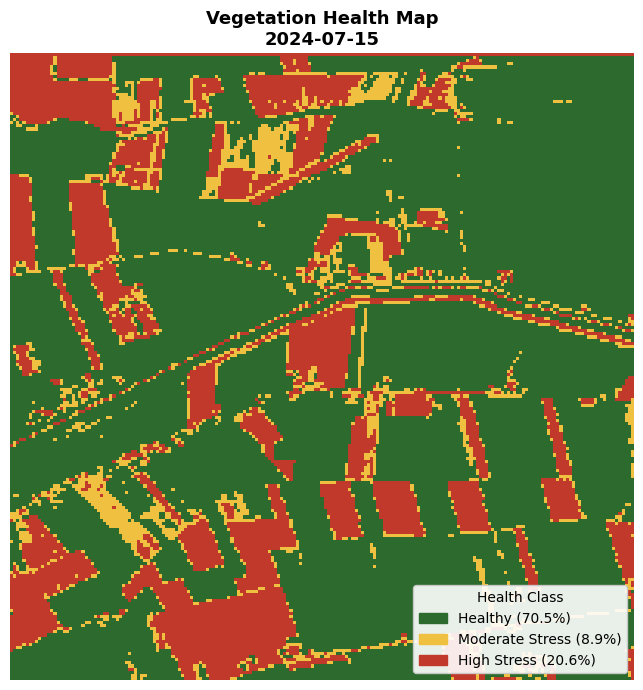

In [ ]:
print('Map 2: Vegetation Health')
plot_health_map(health_map, health_pcts, valid_mask=valid_mask)

Map 3: Water Status


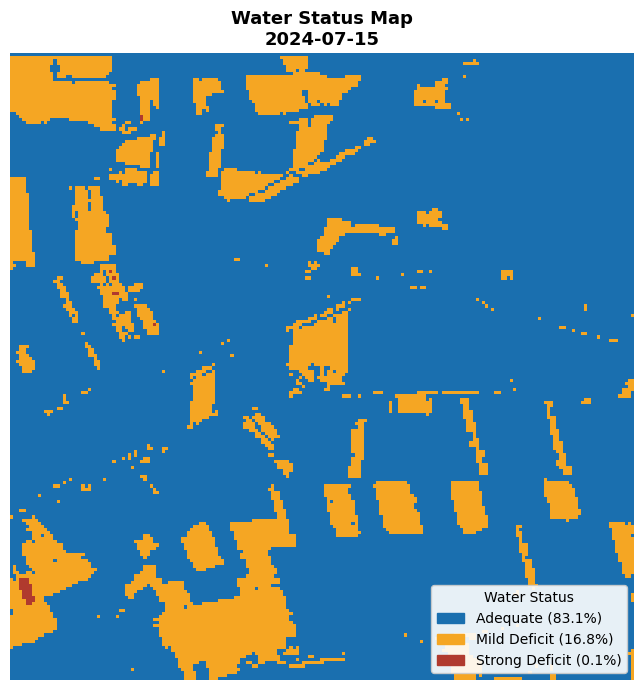

In [ ]:
print('Map 3: Water Status')
plot_water_map(water_map, water_pcts, valid_mask=valid_mask)

Map 4: Uniformity & Hotspots


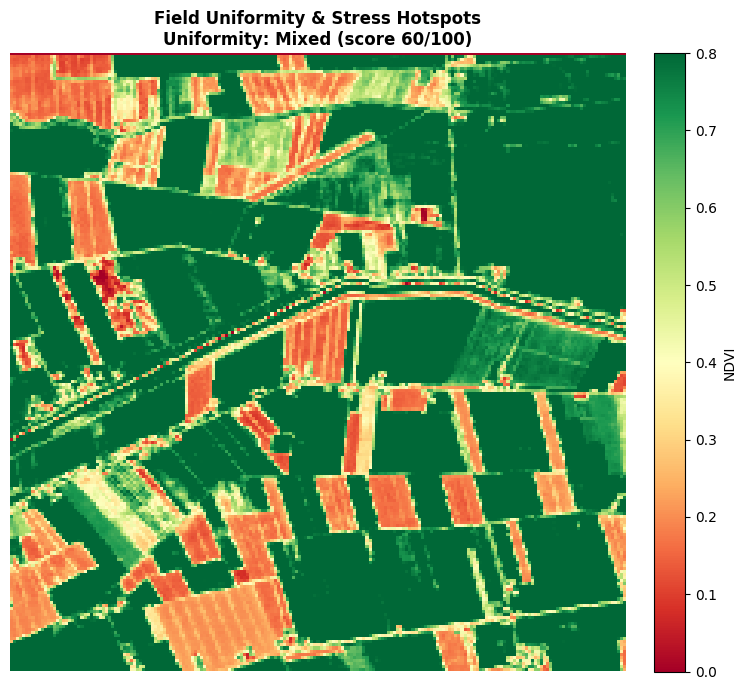

In [ ]:
print('Map 4: Uniformity & Hotspots')
plot_uniformity_hotspots(
    ndvi_arr, hotspot_clusters, anomaly_mask,
    uniformity_score, uniformity_label, valid_mask=valid_mask
)

# Section 9b: Summary Visualizations

Figure 1: Class Breakdown


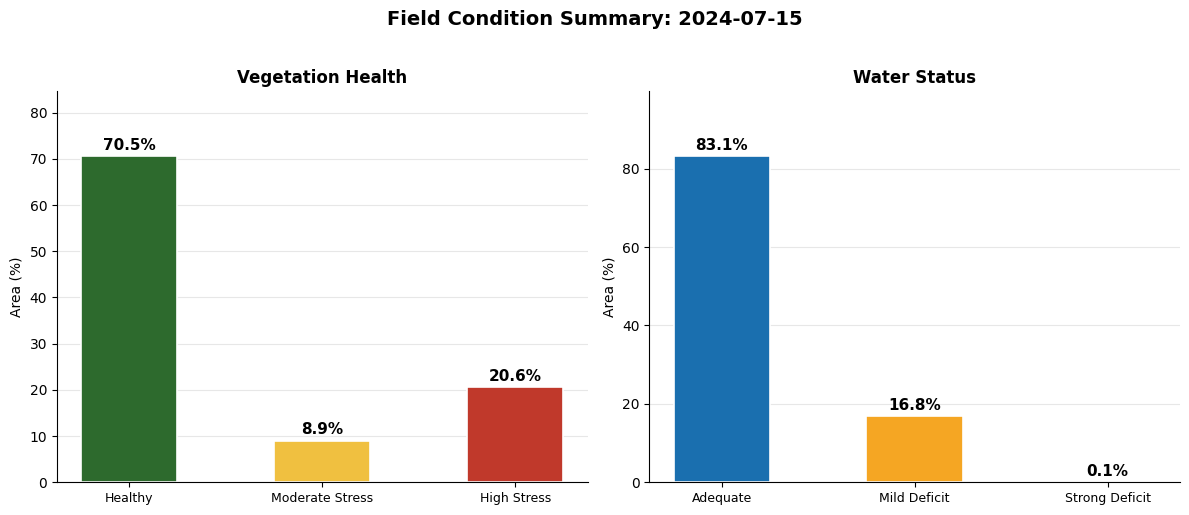

Figure 2: NDVI Distribution


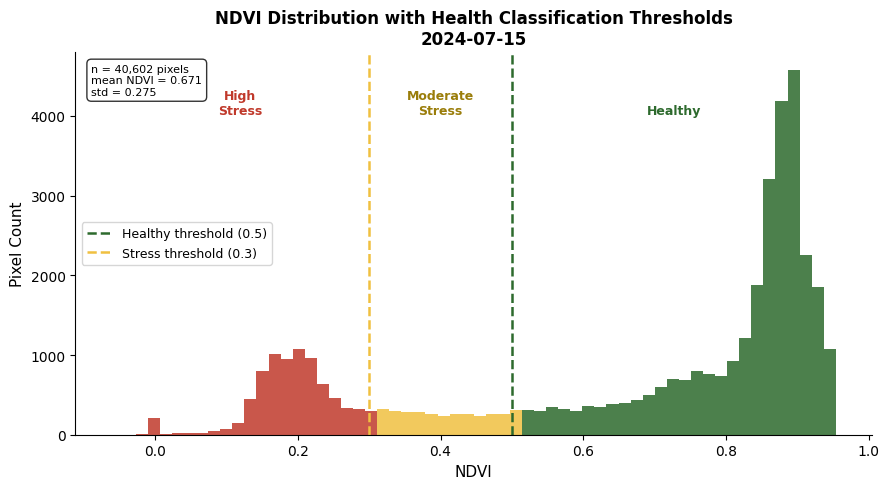

In [ ]:

def plot_class_breakdown(health_pcts, water_pcts):
    """
    side-by-side bar chart showing area percentage breakdown
    for vegetation health and water status classes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Field Condition Summary: {DATE_CENTER}',
                 fontsize=14, fontweight='bold', y=1.02)

    # Health breakdown
    ax1 = axes[0]
    health_labels = list(health_pcts.keys())
    health_values = list(health_pcts.values())
    health_colors = ['#2d6a2d', '#f0c040', '#c0392b']

    bars = ax1.bar(health_labels, health_values, color=health_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)

    for bar, val in zip(bars, health_values):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

    ax1.set_title('Vegetation Health', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Area (%)', fontsize=10)
    ax1.set_ylim(0, max(health_values) * 1.2)
    ax1.set_xticklabels(health_labels, fontsize=9)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.yaxis.grid(True, alpha=0.3)
    ax1.set_axisbelow(True)

    # water breakdown
    ax2 = axes[1]
    water_labels = list(water_pcts.keys())
    water_values = list(water_pcts.values())
    water_colors = ['#1a6faf', '#f5a623', '#b03a2e']

    bars2 = ax2.bar(water_labels, water_values, color=water_colors,
                    edgecolor='white', linewidth=1.2, width=0.5)

    for bar, val in zip(bars2, water_values):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

    ax2.set_title('Water Status', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Area (%)', fontsize=10)
    ax2.set_ylim(0, max(water_values) * 1.2)
    ax2.set_xticklabels(water_labels, fontsize=9)
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.yaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


def plot_ndvi_histogram(ndvi, valid_mask=None, thresholds=HEALTH_THRESHOLDS):
    """
    NDVI pixel distribution with health classification threshold lines overlaid.
    visually justifies threshold choices by showing where natural breaks fall.
    """
    mask = valid_mask if valid_mask is not None else np.ones_like(ndvi, dtype=bool)
    flat_ndvi = ndvi[mask].flatten()
    flat_ndvi = flat_ndvi[np.isfinite(flat_ndvi)]

    h_thresh, m_thresh = thresholds

    fig, ax = plt.subplots(figsize=(9, 5))

    n, bins, patches = ax.hist(flat_ndvi, bins=60, edgecolor='none', alpha=0.85)

    # color bars by health class
    for patch, left_edge in zip(patches, bins[:-1]):
        if left_edge >= h_thresh:
            patch.set_facecolor('#2d6a2d')   # Healthy
        elif left_edge >= m_thresh:
            patch.set_facecolor('#f0c040')   # Moderate Stress
        else:
            patch.set_facecolor('#c0392b')   # High Stress

    # threshold lines
    ax.axvline(h_thresh, color='#2d6a2d', linestyle='--', linewidth=1.8,
               label=f'Healthy threshold ({h_thresh})')
    ax.axvline(m_thresh, color='#f0c040', linestyle='--', linewidth=1.8,
               label=f'Stress threshold ({m_thresh})')

    # annotate class regions
    ymax = n.max()
    ax.text((flat_ndvi.min() + m_thresh) / 2, ymax * 0.88,
            'High\nStress', color='#c0392b', ha='center', fontsize=9, fontweight='bold')
    ax.text((m_thresh + h_thresh) / 2, ymax * 0.88,
            'Moderate\nStress', color='#9a7d0a', ha='center', fontsize=9, fontweight='bold')
    ax.text((h_thresh + min(flat_ndvi.max(), 1.0)) / 2, ymax * 0.88,
            'Healthy', color='#2d6a2d', ha='center', fontsize=9, fontweight='bold')

    ax.set_xlabel('NDVI', fontsize=11)
    ax.set_ylabel('Pixel Count', fontsize=11)
    ax.set_title(f'NDVI Distribution with Health Classification Thresholds\n{DATE_CENTER}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # summary stats box
    stats_text = (f'n = {len(flat_ndvi):,} pixels\n'
                  f'mean NDVI = {flat_ndvi.mean():.3f}\n'
                  f'std = {flat_ndvi.std():.3f}')
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
            fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# render summary figures
print('Figure 1: Class Breakdown')
plot_class_breakdown(health_pcts, water_pcts)

print('Figure 2: NDVI Distribution')
plot_ndvi_histogram(ndvi_arr, valid_mask=valid_mask)

---
## Section 10: Automated Agronomic Report

**Note**: The quadrant breakdown allows spatial localization of stress (e.g. "northeast quadrant") rather than global percentages alone. Rainfall context allows the report to distinguish drought stress from irrigation/soil issues.

In [ ]:
def find_worst_quadrant(quadrant_stats, stress_key='stress_pct'):
    """
    identifies the quadrant with the highest stress/deficit percentage.
    """
    if not quadrant_stats:
        return 'unknown'
    worst = max(quadrant_stats.items(), key=lambda x: x[1].get(stress_key, 0))
    names = {'NW': 'northwest', 'NE': 'northeast', 'SW': 'southwest', 'SE': 'southeast'}
    return names.get(worst[0], worst[0])


def interpret_rainfall_context(rainfall_class, water_pcts):
    """
    generates an agronomic interpretation sentence based on
    the combination of water deficit and recent rainfall.
    """
    has_deficit = (water_pcts.get('Mild Deficit', 0) + water_pcts.get('Strong Deficit', 0)) > 15

    if rainfall_class == 'Unknown' or rainfall_class is None:
        return 'Rainfall data was unavailable for this region and period.'

    if has_deficit and rainfall_class == 'Low':
        return ('Recent 30-day rainfall was low, suggesting observed water deficit '
                'is likely driven by drought conditions.')
    elif has_deficit and rainfall_class in ('Moderate', 'Adequate'):
        return ('Recent 30-day rainfall was adequate, suggesting water deficit may reflect '
                'irrigation variability, drainage issues, or soil heterogeneity rather than drought.')
    elif not has_deficit and rainfall_class == 'Low':
        return ('Despite low recent rainfall, the field shows adequate water status — '
                'likely supported by irrigation.')
    else:
        return f'Recent 30-day rainfall was {rainfall_class.lower()}, consistent with observed water conditions.'


def generate_report(health_pcts, water_pcts, uniformity_score, uniformity_label,
                    hotspot_clusters, health_quadrants, water_quadrants,
                    rainfall_total, rainfall_class, date_center, n_scenes):
    """
    generating report

    uses quadrant-aware spatial statistics and CHIRPS rainfall context
    to produce human-readable interpretation beyond raw percentages.
    """
    worst_health_q = find_worst_quadrant(health_quadrants, stress_key='stress_pct')
    worst_water_q  = find_worst_quadrant(water_quadrants,  stress_key='deficit_pct')

    total_stress_pct  = health_pcts.get('Moderate Stress', 0) + health_pcts.get('High Stress', 0)
    total_deficit_pct = water_pcts.get('Mild Deficit', 0) + water_pcts.get('Strong Deficit', 0)

    hotspot_locations = ', '.join([hs['quadrant'] for hs in hotspot_clusters]) \
                        if hotspot_clusters else 'not identified'

    rainfall_sentence = interpret_rainfall_context(rainfall_class, water_pcts)
    rainfall_line = (f'  30-day cumulative rainfall for the AOI was {rainfall_total:.1f} mm '
                     f'(classified: {rainfall_class}).') \
                    if rainfall_total is not None else '  Rainfall data was unavailable.'

    report = f"""

 FIELD CONDITION REPORT
 Date: {date_center}  |  Sentinel-2 scenes used: {n_scenes}


VEGETATION HEALTH
  The field is predominantly {max(health_pcts, key=health_pcts.get)} \
({health_pcts[max(health_pcts, key=health_pcts.get)]:.1f}% of area).
  Moderate Stress covers {health_pcts['Moderate Stress']:.1f}% and \
High Stress covers {health_pcts['High Stress']:.1f}% of the field.
  Stress is most concentrated in the {worst_health_q} quadrant.
  Total stressed area: {total_stress_pct:.1f}%.

WATER STATUS
  Water conditions are {max(water_pcts, key=water_pcts.get)} \
across {water_pcts[max(water_pcts, key=water_pcts.get)]:.1f}% of the field.
  Mild Deficit: {water_pcts['Mild Deficit']:.1f}%  |  \
Strong Deficit: {water_pcts['Strong Deficit']:.1f}%.
  Water deficit is most pronounced in the {worst_water_q} quadrant.
{rainfall_line}
  {rainfall_sentence}

FIELD UNIFORMITY
  Uniformity score: {uniformity_score}/100 —> classified as {uniformity_label}.
  {len(hotspot_clusters)} stress hotspot zone(s) identified \
(Isolation Forest + DBSCAN spatial clustering).
  Hotspot locations: {hotspot_locations}.

RECOMMENDED ATTENTION ZONES
  Priority zones for ground investigation: {worst_health_q} (vegetation stress) \
and {worst_water_q} (water deficit).
  {'These zones overlap, suggesting a combined stress event.'
   if worst_health_q == worst_water_q
   else 'These zones differ, suggesting independent stress drivers.'}

"""
    return report


# generate and print report
report = generate_report(
    health_pcts, water_pcts, uniformity_score, uniformity_label,
    hotspot_clusters, health_quadrants, water_quadrants,
    rainfall_total, rainfall_class, DATE_CENTER, n_scenes
)
print(report)



 FIELD CONDITION REPORT
 Date: 2024-07-15  |  Sentinel-2 scenes used: 4


VEGETATION HEALTH
  The field is predominantly Healthy (70.5% of area).
  Moderate Stress covers 8.9% and High Stress covers 20.6% of the field.
  Stress is most concentrated in the northwest quadrant.
  Total stressed area: 29.5%.

WATER STATUS
  Water conditions are Adequate across 83.1% of the field.
  Mild Deficit: 16.8%  |  Strong Deficit: 0.1%.
  Water deficit is most pronounced in the northwest quadrant.
  30-day cumulative rainfall for the AOI was 42.8 mm (classified: Moderate).
  Recent 30-day rainfall was adequate, suggesting water deficit may reflect irrigation variability, drainage issues, or soil heterogeneity rather than drought.

FIELD UNIFORMITY
  Uniformity score: 60/100 —> classified as Mixed.
  0 stress hotspot zone(s) identified (Isolation Forest + DBSCAN spatial clustering).
  Hotspot locations: not identified.

RECOMMENDED ATTENTION ZONES
  Priority zones for ground investigation: northwes

---
## Section 11: Extending This System

Below are some next steps for each direction in the system roadmap.

### 1. Multi-Field Scaling
Every function accepts `aoi` and `date_center` as parameters —> no refactoring needed.
```python
# Example: batch processing a field registry
field_registry = pd.read_csv('fields.csv')  # columns: field_id, lat, lon, date
results = []
for _, row in field_registry.iterrows():
    aoi = define_aoi(lat=row.lat, lon=row.lon, buffer_km=2.0)
    composite, _ = load_sentinel2(aoi, row.date)
    indices = compute_indices(composite)
    # ... run full pipeline, collect outputs
    results.append({'field_id': row.field_id, 'health_pcts': health_pcts, ...})
```

### 2. Temporal Change Detection
Call `load_sentinel2()` across monthly intervals for the same AOI.  
Track NDVI/NDWI trends over time → early stress warning system.
```python
dates = pd.date_range('2024-04-01', '2024-09-01', freq='MS').strftime('%Y-%m-%d')
ndvi_time_series = [download_band(compute_indices(load_sentinel2(AOI, d)[0]), 'NDVI', AOI) for d in dates]
# Plot mean NDVI per date -> crop growth curve + anomaly detection over time
```

### 3. Deforestation Monitoring Adaptation
Same pipeline structure, different index stack:
- Replace NDVI/EVI with **NDFI** (Normalized Difference Fraction Index) —> standard for tropical forest canopy degradation detection
- Replace water indices with **NBR** (Normalized Burn Ratio) for fire/clearing detection
- Isolation Forest anomaly detection transfers directly —> forest loss pixels are multivariate outliers

### 4. Additional Environmental Indicators
CHIRPS rainfall (Section 5) is the first layer of multi-source integration. Potential additions:
- **Soil moisture:** ESA CCI Soil Moisture product (available in GEE: `NASA_USDA/HSL/SMAP10KM_soil_moisture`)
- **Temperature stress:** MODIS Land Surface Temperature (`MODIS/061/MOD11A1`)
- **Crop type context:** ESA WorldCover land classification (`ESA/WorldCover/v200`) to mask non-agricultural pixels

